In [1]:
# Imports

import sys
sys.path.append("..")

import torch
import numpy as np
import matplotlib.pyplot as plt

from src.dataset import LEVIRCDDataset, build_dataloaders, precrop_dataset, IMAGENET_MEAN, IMAGENET_STD

In [2]:
# Precrop dataset (run once)

precrop_dataset(
    src_dir="../data/raw/LEVIR-CD",
    dst_dir="../data/patches",
    patch_size=256,
)

Cropping 445 images from A/train
Cropping 64 images from A/val
Cropping 128 images from A/test
Cropping 445 images from B/train
Cropping 64 images from B/val
Cropping 128 images from B/test
Cropping 445 images from label/train
Cropping 64 images from label/val
Cropping 128 images from label/test
Pre-cropping complete. Patches saved to ..\data\patches


In [3]:
# Load dataset

train_ds = LEVIRCDDataset(root="../data/patches/train", augment=True)
val_ds = LEVIRCDDataset(root="../data/patches/val", augment=False)

print(f"Train samples: {len(train_ds)}")
print(f"Val samples: {len(val_ds)}")

sample = train_ds[0]
print(f"Sample keys: {sample.keys()}")
print(f"A shape: {sample['A'].shape}")
print(f"B shape: {sample['B'].shape}")
print(f"Mask shape: {sample['mask'].shape}")
print(f"Mask unique values: {sample['mask'].unique()}")

Loaded 7120 samples from ../data/patches/train with augment=True
Loaded 1024 samples from ../data/patches/val with augment=False
Train samples: 7120
Val samples: 1024
Sample keys: dict_keys(['A', 'B', 'mask', 'name'])
A shape: torch.Size([3, 256, 256])
B shape: torch.Size([3, 256, 256])
Mask shape: torch.Size([1, 256, 256])
Mask unique values: tensor([0., 1.])


In [4]:
# Denormalize Helper

def denormalize(tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    img = tensor * std + mean
    return img.clamp(0, 1).permute(1, 2, 0).numpy()

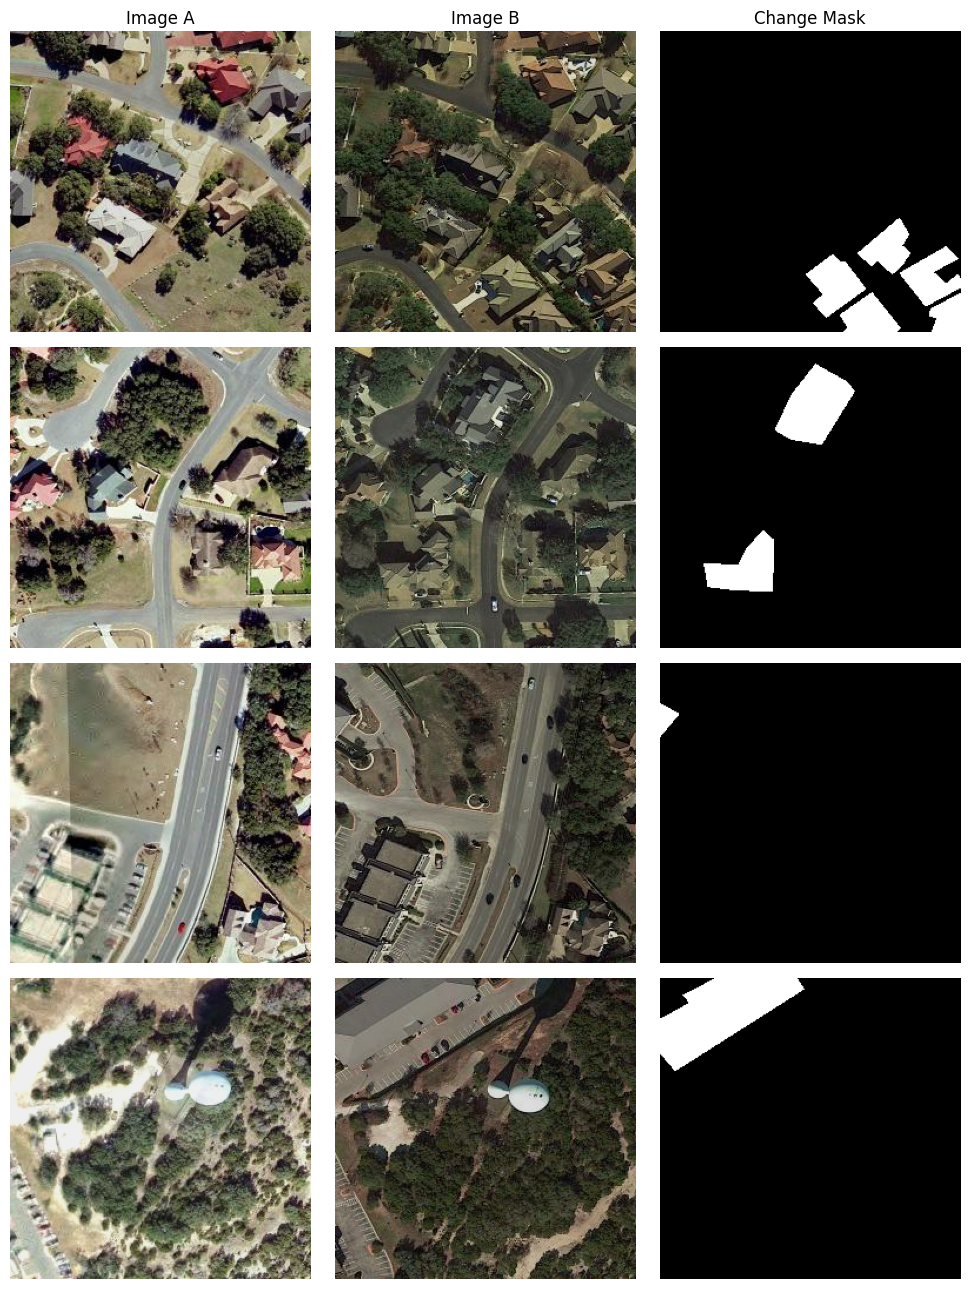

In [5]:
# Visualize triplets

fig, axs = plt.subplots(4, 3, figsize=(10, 13))
axs[0,0].set_title("Image A")
axs[0,1].set_title("Image B")
axs[0,2].set_title("Change Mask")

for row in range(4):
    sample = train_ds[row]
    axs[row, 0].imshow(denormalize(sample["A"]))
    axs[row, 1].imshow(denormalize(sample["B"]))
    axs[row, 2].imshow(sample["mask"].squeeze(), cmap="gray")

    for col in range(3):
        axs[row, col].axis("off")

plt.tight_layout()
plt.show()

Mean change ratio: 0.0409
Std: 0.0792
Min: 0.0000
Max: 0.3513


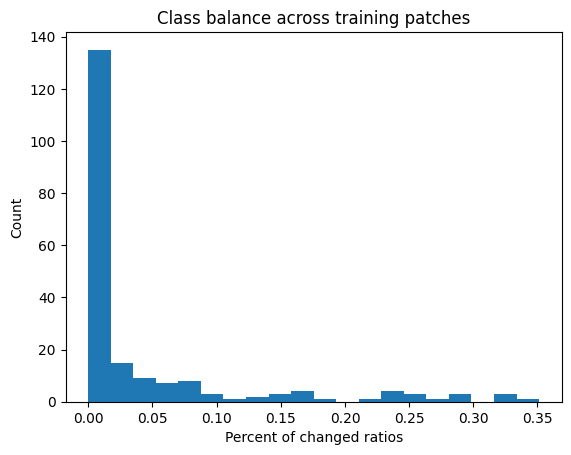

In [8]:
# Check class balance

n_samples = 200
change_ratios = []

for i in range(0, len(train_ds), len(train_ds) // n_samples):
    mask  = train_ds[i]["mask"]
    change_ratios.append(mask.mean().item())

print(f"Mean change ratio: {np.mean(change_ratios):.4f}")
print(f"Std: {np.std(change_ratios):.4f}")
print(f"Min: {np.min(change_ratios):.4f}")
print(f"Max: {np.max(change_ratios):.4f}")

plt.hist(change_ratios, bins=20)
plt.xlabel("Percent of changed ratios")
plt.ylabel("Count")
plt.title("Class balance across training patches")
plt.show()

In [9]:
# Test dataloader

loaders = build_dataloaders("../data/patches", batch_size=8, num_workers=0)

batch = next(iter(loaders["train"]))
print(f"Batch A shape: {batch['A'].shape}")
print(f"Batch B shape: {batch['B'].shape}")
print(f"Batch mask shape: {batch['mask'].shape}")
print(f"Batch dtypes: A={batch['A'].dtype}, B={batch['B'].dtype}, mask={batch['mask'].dtype}")

Loaded 7120 samples from ../data/patches\train with augment=True
Loaded 1024 samples from ../data/patches\val with augment=False
Loaded 2048 samples from ../data/patches\test with augment=False
Batch A shape: torch.Size([8, 3, 256, 256])
Batch B shape: torch.Size([8, 3, 256, 256])
Batch mask shape: torch.Size([8, 1, 256, 256])
Batch dtypes: A=torch.float32, B=torch.float32, mask=torch.float32


c:\Users\NJPar\Documents\Github Projects\levir-cd-change-detection\.venv\lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


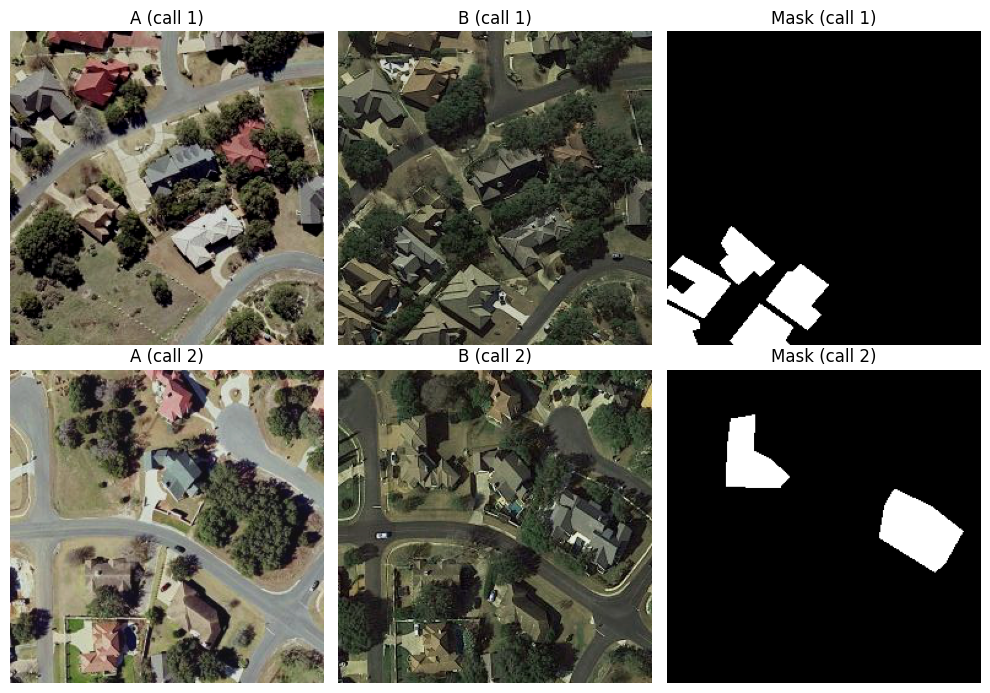

In [11]:
# Verify augmentation

fig, axs = plt.subplots(2, 3, figsize=(10, 7))

for row in range(2):
    sample = train_ds[row]
    axs[row, 0].imshow(denormalize(sample["A"]))
    axs[row, 1].imshow(denormalize(sample["B"]))
    axs[row, 2].imshow(sample["mask"].squeeze(), cmap="gray")

    for col in range(3):
        axs[row, col].axis("off")

axs[0,0].set_title("A (call 1)")
axs[0,1].set_title("B (call 1)")
axs[0,2].set_title("Mask (call 1)")
axs[1,0].set_title("A (call 2)")
axs[1,1].set_title("B (call 2)")
axs[1,2].set_title("Mask (call 2)")
plt.tight_layout()
plt.show()